# Compuertas Lógicas con Aprendizaje — Perceptrón
### Módulo 3 — Versión optimizada con gráficas de evolución


Aquí el perceptrón ** aprende solo** usando la regla de actualización:

```
error    = target - salida           ← qué tan equivocado estuvo
w_nuevo  = w_viejo + lr * error * x  ← ajustar el peso proporcional al error
b_nuevo  = b_viejo + lr * error      ← ajustar el bias igual
```

- Si `error = 0` → acertó → los pesos NO cambian
- Si `error = +1` → predijo 0, era 1 → pesos **suben**
- Si `error = -1` → predijo 1, era 0 → pesos **bajan**

El parámetro `learning_rate` (lr) controla qué tan grande es cada ajuste.

In [2]:
# ═══════════════════════════════════════════════════════════════
# CELDA 1 — Imports y path al machote
# ═══════════════════════════════════════════════════════════════
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

# Ruta relativa al machote (sube dos niveles desde Modulo-3/Clases/)
RUTA = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'Machote'))
if RUTA not in sys.path:
    sys.path.append(RUTA)

# Si la ruta relativa falla
# sys.path.append(r"D:/Proyectos/Diplomado-RNA/Machote")  # Windows
# sys.path.append("/home/usr/Diplomado-RNA/Machote")      # Linux

# Intentamos importar mostrar_resultados del machote
# Si no está disponible, definimos una versión local
try:
    from machote_ML import mostrar_resultados
    print("Machote importado ✅")
except ImportError:
    print("Machote no encontrado — usando versión local de mostrar_resultados")

    def to_scalar(val):
        """Convierte numpy array de 1 elemento a float, o devuelve float si ya es escalar."""
        if hasattr(val, 'flat'):
            return float(val.flat[0])
        return float(val)

    def mostrar_resultados(nombre, inputs, targets, outputs):
        """Muestra tabla de resultados con ✅/❌ usando tabulate."""
        filas = []
        for i in range(len(outputs)):
            x1  = int(inputs[i][0])
            x2  = int(inputs[i][1])
            h   = round(to_scalar(outputs[i][0]), 4) # round para mostrar la salida del perceptrón antes de la función escalón con 4 decimales
            fh  = int(to_scalar(outputs[i][1])) # Aplicamos función escalón a la salida del perceptrón para obtener 0 o 1
            tgt = int(targets[i])       # 
            ok  = '✅' if fh == tgt else '❌'
            filas.append([x1, x2, h, fh, tgt, ok])

        correctos = sum(1 for f in filas if f[-1] == '✅')
        print(f"\n{'═'*55}")
        print(f"  Compuerta {nombre}")
        print(f"{'═'*55}")
        print(tabulate(filas, headers=['X1','X2','h','f(h)','Target','OK'], tablefmt='grid'))
        if correctos == len(filas):
            print(f"  Resultado: {correctos}/{len(filas)} correctos ✅")
        else:
            print(f"  Resultado: {correctos}/{len(filas)} correctos ❌")

print("Imports listos ✅")

✅ machote_ML cargado correctamente

Funciones disponibles:
  CARGAR:   cargar_desde_sklearn | cargar_desde_uci | cargar_desde_csv
  EXPLORAR: resumen_rapido | ver_distribucion | ver_correlacion_con_y | ver_mapa_calor
  PREPARAR: seleccionar_features | dividir_datos | escalar_datos | binarizar_datos
  EVALUAR:  evaluar_clasificacion | evaluar_regresion | comparar_modelos
Machote no encontrado — usando versión local de mostrar_resultados
Imports listos ✅


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELDA 2 — Función de activación
# ═══════════════════════════════════════════════════════════════
def escalon_unitario(x):
    """
    Función de activación escalón unitario.
    Devuelve 1 si x >= 0, sino 0.
    Se usa en el perceptrón porque la salida debe ser exactamente 0 o 1.
    """
    val = float(x.flat[0]) if hasattr(x, 'flat') else float(x) # hasattr verifica si x tiene el atributo 'flat' (numpy array), si es así lo convierte a float, sino lo convierte directamente
    return 1 if val >= 0 else 0

print("Función de activación definida ✅")

Función de activación definida ✅


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3 — Función principal de entrenamiento con gráficas
# ═══════════════════════════════════════════════════════════════

def entrenar_perceptron(nombre, inputs, targets,
                        learning_rate=0.01, epochs=100_000,
                        seed=42, verbose=False):
    """
    Entrena un perceptrón con la regla de aprendizaje de Rosenblatt.

    Parámetros:
        nombre        → nombre de la compuerta (para los títulos)
        inputs        → array (4,2) con las 4 combinaciones de entrada
        targets       → array (4,) con las salidas esperadas
        learning_rate → qué tan grandes son los ajustes de pesos (0.01 a 1.0)
        epochs        → cuántas veces pasa por todo el dataset
        seed          → semilla para reproducibilidad (mismos pesos iniciales)
        verbose       → si True, imprime el detalle de cada época

    Regresa:
        historial → dict con listas de error_total, w1, w2 y bias por época
                    Útil para graficar la evolución del entrenamiento.
    """
    # Inicializar pesos con números aleatorios pequeños
    # seed fija la aleatoriedad → los resultados son reproducibles
    np.random.seed(seed)
    weights = np.random.rand(2) * 0.1  # pequeños para empezar cerca de 0
    bias    = np.random.rand(1) * 0.1

    print(f"\n{'═'*55}")
    print(f"  Perceptrón: {nombre}")
    print(f"  lr={learning_rate}  epochs={epochs}  seed={seed}")
    print(f"{'═'*55}")
    print(f"  Pesos iniciales: W1={weights[0]:.4f}  W2={weights[1]:.4f}  b={bias[0]:.4f}")

    # Historial — guardamos los valores de cada época para graficar después
    historial = {
        'error_total': [],  # error total por época (suma de |errores|)
        'w1':          [],  # valor de W1 al final de cada época
        'w2':          [],  # valor de W2 al final de cada época
        'bias':        [],  # valor del bias al final de cada época
        'accuracy':    [],  # % de aciertos por época
    }

    epocas_hasta_convergencia = None  # época donde el error llegó a 0

    for epoch in range(epochs):
        error_total = 0
        correctos   = 0

        if verbose:
            print(f"\n  ── Época {epoch+1} ──")
            print(f"  {'X1':>3} {'X2':>3} {'Target':>7} {'Salida':>7} {'Error':>7}")

        for i in range(len(inputs)):
            x      = inputs[i]
            target = targets[i]

            # 1. Suma ponderada (combinación lineal)
            h = np.dot(x, weights) + bias

            # 2. Función de activación → salida binaria
            y = escalon_unitario(h)

            # 3. Calcular error
            error = int(target) - int(y)
            error_total += abs(error) # abs devuelve el valor absoluto del error, para contar cuántos errores hubo sin importar si fueron positivos o negativos
            if error == 0:
                correctos += 1

            # 4. Actualizar pesos SOLO si hubo error
            #    w_nuevo = w_viejo + lr * error * x
            #    Si error=0 → no cambia nada
            #    Si error≠0 → se mueve en la dirección del error
            if error != 0:
                weights = weights + learning_rate * error * x
                bias    = bias    + learning_rate * error

            if verbose:
                print(f"  {x[0]:>3} {x[1]:>3} {target:>7} {y:>7} {error:>7}")

        # Guardar estado al final de cada época
        historial['error_total'].append(error_total)
        historial['w1'].append(float(weights[0]))
        historial['w2'].append(float(weights[1]))
        historial['bias'].append(float(bias[0]))
        historial['accuracy'].append(correctos / len(inputs) * 100)

        if verbose:
            print(f"  Error total: {error_total}  |  Accuracy: {correctos}/{len(inputs)}")

        # Parar temprano si ya no hay errores (siempre, sin importar verbose)
        if error_total == 0 and epocas_hasta_convergencia is None:
            epocas_hasta_convergencia = epoch + 1
            if verbose:
                print(f"  🛑 Convergencia alcanzada — deteniendo en época {epocas_hasta_convergencia}")
            break  # siempre frenamos al converger

    # Resultado final
    print(f"\n  Pesos finales:   W1={weights[0]:.4f}  W2={weights[1]:.4f}  b={float(bias[0]):.4f}")
    if epocas_hasta_convergencia:
        print(f"  ✅ Convergió en la época {epocas_hasta_convergencia}")
    else:
        print(f"  ⚠️  No convergió en {epochs} épocas")

    # Tabla de resultados con los pesos finales aprendidos
    outputs_finales = []
    for i in range(len(inputs)):
        h = np.dot(inputs[i], weights) + bias
        y = escalon_unitario(h)
        outputs_finales.append([h, y])

    mostrar_resultados(nombre, inputs, targets, outputs_finales)

    return historial


print("Función de entrenamiento definida ✅")

Función de entrenamiento definida ✅


In [5]:
# ═══════════════════════════════════════════════════════════════
# CELDA 4 — Función para graficar la evolución por épocas
# ═══════════════════════════════════════════════════════════════

def graficar_evolucion(nombre, historial):
    """
    Grafica cómo evolucionaron el error, accuracy y pesos a lo largo
    de las épocas de entrenamiento.

    ¿Por qué graficamos esto?
    - Error por época → ver cuándo el modelo deja de equivocarse
    - Accuracy por época → ver cuándo alcanza el 100%
    - Pesos y bias → ver cómo cambian los valores que el modelo aprende

    Si el error baja rápido → el modelo aprende bien.
    Si el error oscila o no baja → puede necesitar más épocas o menor lr.

    Parámetros:
        nombre    → nombre de la compuerta (para los títulos)
        historial → dict devuelto por entrenar_perceptron()
    """
    epocas = list(range(1, len(historial['error_total']) + 1))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Evolución del aprendizaje — Compuerta {nombre}', fontsize=14, fontweight='bold')

    # ── Gráfica 1: Error total por época ─────────────────────
    # Muestra cuántos errores comete en total en cada época.
    # Una curva que baja a 0 = el perceptrón aprendió correctamente.
    axes[0].plot(epocas, historial['error_total'], 'ro-', linewidth=2, markersize=6)
    axes[0].fill_between(epocas, historial['error_total'], alpha=0.15, color='red')
    axes[0].axhline(y=0, color='green', linewidth=1.5, linestyle='--', label='Error = 0 (convergió)')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Número de errores')
    axes[0].set_title('Error total por época')
    axes[0].set_xticks(epocas)
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Marcar la época de convergencia si existe
    if 0 in historial['error_total']:
        conv = historial['error_total'].index(0) + 1
        axes[0].axvline(x=conv, color='green', linewidth=1, linestyle=':', alpha=0.7)
        axes[0].annotate(f'Convergió\nép. {conv}',
                         xy=(conv, 0), xytext=(conv + 0.3, 1),
                         fontsize=8, color='green')

    # ── Gráfica 2: Accuracy por época ────────────────────────
    # Muestra qué % de las 4 entradas predijo correctamente en cada época.
    # Cuando llega al 100% → el perceptrón implementa la compuerta correctamente.
    axes[1].plot(epocas, historial['accuracy'], 'b^-', linewidth=2, markersize=6)
    axes[1].axhline(y=100, color='green', linewidth=1.5, linestyle='--', label='100% accuracy')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy por época')
    axes[1].set_ylim(0, 110)
    axes[1].set_xticks(epocas)
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    # ── Gráfica 3: Evolución de pesos y bias ─────────────────
    # Muestra cómo cambian los pesos W1, W2 y el bias a lo largo del tiempo.
    # Cuando se estabilizan (líneas planas) → los pesos convergieron.
    # Si siguen oscilando → puede necesitar más épocas o menor learning_rate.
    axes[2].plot(epocas, historial['w1'],   's-', color='#3B8BD4', linewidth=2, markersize=6, label='W1')
    axes[2].plot(epocas, historial['w2'],   'o-', color='#D85A30', linewidth=2, markersize=6, label='W2')
    axes[2].plot(epocas, historial['bias'], 'd-', color='#2ca02c', linewidth=2, markersize=6, label='bias')
    axes[2].axhline(y=0, color='gray', linewidth=0.8, linestyle='--')
    axes[2].set_xlabel('Época')
    axes[2].set_ylabel('Valor del parámetro')
    axes[2].set_title('Evolución de pesos y bias')
    axes[2].set_xticks(epocas)
    axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


print("Función de gráficas definida ✅")

Función de gráficas definida ✅


---
# Entrenamiento por compuerta

Ahora entrenamos cada compuerta y vemos cómo aprende época por época.

Lo que veremos en las gráficas:
- **Error total** → cuántas predicciones falló en cada época (queremos que llegue a 0)
- **Accuracy** → % de aciertos por época (queremos que llegue al 100%)
- **Pesos** → cómo cambian W1, W2 y bias hasta estabilizarse


═══════════════════════════════════════════════════════
  Perceptrón: OR
  lr=0.01  epochs=200000  seed=42
═══════════════════════════════════════════════════════
  Pesos iniciales: W1=0.0375  W2=0.0951  b=0.0732

  ── Época 1 ──
   X1  X2  Target  Salida   Error
    0   0       0       1      -1
    0   1       1       1       0
    1   0       1       1       0
    1   1       1       1       0
  Error total: 1  |  Accuracy: 3/4

  ── Época 2 ──
   X1  X2  Target  Salida   Error
    0   0       0       1      -1
    0   1       1       1       0
    1   0       1       1       0
    1   1       1       1       0
  Error total: 1  |  Accuracy: 3/4

  ── Época 3 ──
   X1  X2  Target  Salida   Error
    0   0       0       1      -1
    0   1       1       1       0
    1   0       1       1       0
    1   1       1       1       0
  Error total: 1  |  Accuracy: 3/4

  ── Época 4 ──
   X1  X2  Target  Salida   Error
    0   0       0       1      -1
    0   1       1       1       0
 

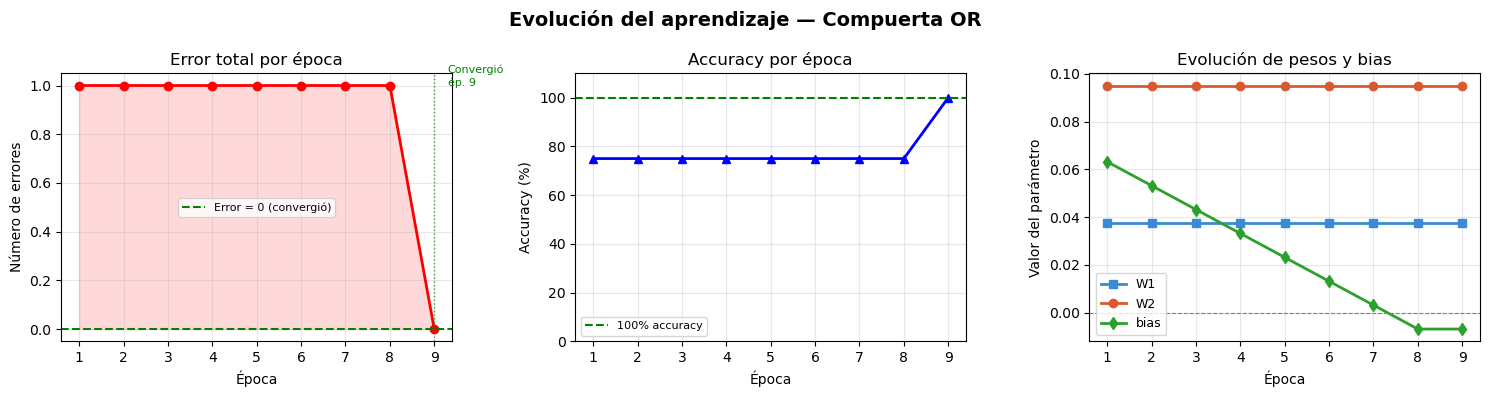

In [6]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5 — Compuerta OR
# ═══════════════════════════════════════════════════════════════
inputs  = np.array([[0,0],[0,1],[1,0],[1,1]])
targets = np.array([0, 1, 1, 1])   # OR

hist_or = entrenar_perceptron(
    nombre='OR',
    inputs=inputs,
    targets=targets,
    learning_rate=0.01,
    epochs=200_000,
    seed=42,
    verbose=True    # ← True para ver el detalle fila por fila de cada época
)

graficar_evolucion('OR', hist_or)


═══════════════════════════════════════════════════════
  Perceptrón: AND
  lr=0.01  epochs=200000  seed=42
═══════════════════════════════════════════════════════
  Pesos iniciales: W1=0.0375  W2=0.0951  b=0.0732

  ── Época 1 ──
   X1  X2  Target  Salida   Error
    0   0       0       1      -1
    0   1       0       1      -1
    1   0       0       1      -1
    1   1       1       1       0
  Error total: 3  |  Accuracy: 1/4

  ── Época 2 ──
   X1  X2  Target  Salida   Error
    0   0       0       1      -1
    0   1       0       1      -1
    1   0       0       1      -1
    1   1       1       1       0
  Error total: 3  |  Accuracy: 1/4

  ── Época 3 ──
   X1  X2  Target  Salida   Error
    0   0       0       1      -1
    0   1       0       1      -1
    1   0       0       1      -1
    1   1       1       1       0
  Error total: 3  |  Accuracy: 1/4

  ── Época 4 ──
   X1  X2  Target  Salida   Error
    0   0       0       0       0
    0   1       0       1      -1


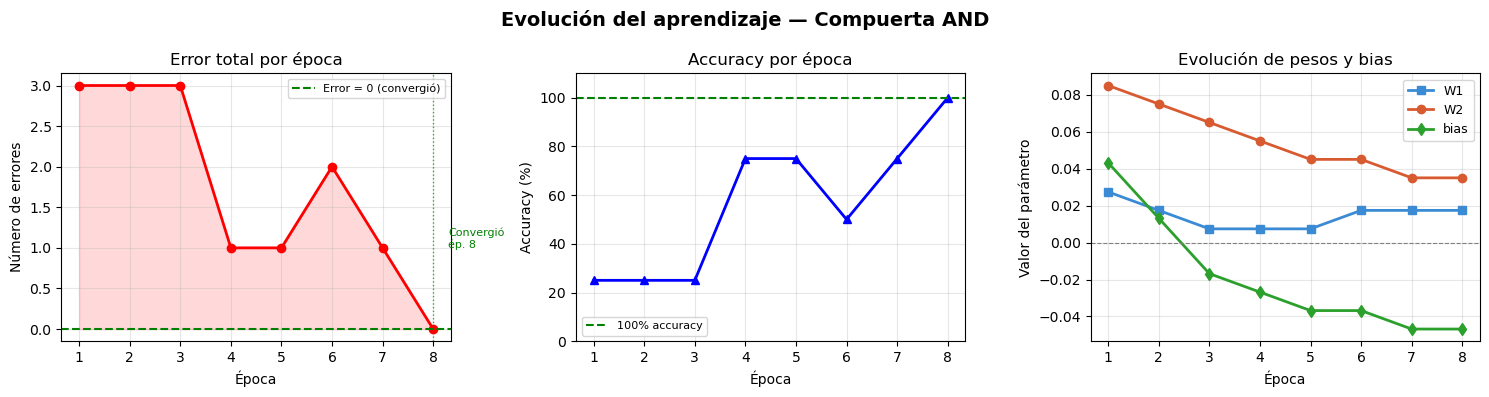

In [7]:
# ═══════════════════════════════════════════════════════════════
# CELDA 6 — Compuerta AND
# ═══════════════════════════════════════════════════════════════
targets_and = np.array([0, 0, 0, 1])  # AND

hist_and = entrenar_perceptron(
    nombre='AND',
    inputs=inputs,
    targets=targets_and,
    learning_rate=0.01,
    epochs=200_000,
    seed=42,
    verbose=True
)

graficar_evolucion('AND', hist_and)


═══════════════════════════════════════════════════════
  Perceptrón: NOR
  lr=0.01  epochs=200000  seed=42
═══════════════════════════════════════════════════════
  Pesos iniciales: W1=0.0375  W2=0.0951  b=0.0732

  ── Época 1 ──
   X1  X2  Target  Salida   Error
    0   0       1       1       0
    0   1       0       1      -1
    1   0       0       1      -1
    1   1       0       1      -1
  Error total: 3  |  Accuracy: 1/4

  ── Época 2 ──
   X1  X2  Target  Salida   Error
    0   0       1       1       0
    0   1       0       1      -1
    1   0       0       1      -1
    1   1       0       1      -1
  Error total: 3  |  Accuracy: 1/4

  ── Época 3 ──
   X1  X2  Target  Salida   Error
    0   0       1       1       0
    0   1       0       1      -1
    1   0       0       1      -1
    1   1       0       1      -1
  Error total: 3  |  Accuracy: 1/4

  ── Época 4 ──
   X1  X2  Target  Salida   Error
    0   0       1       0       1
    0   1       0       1      -1


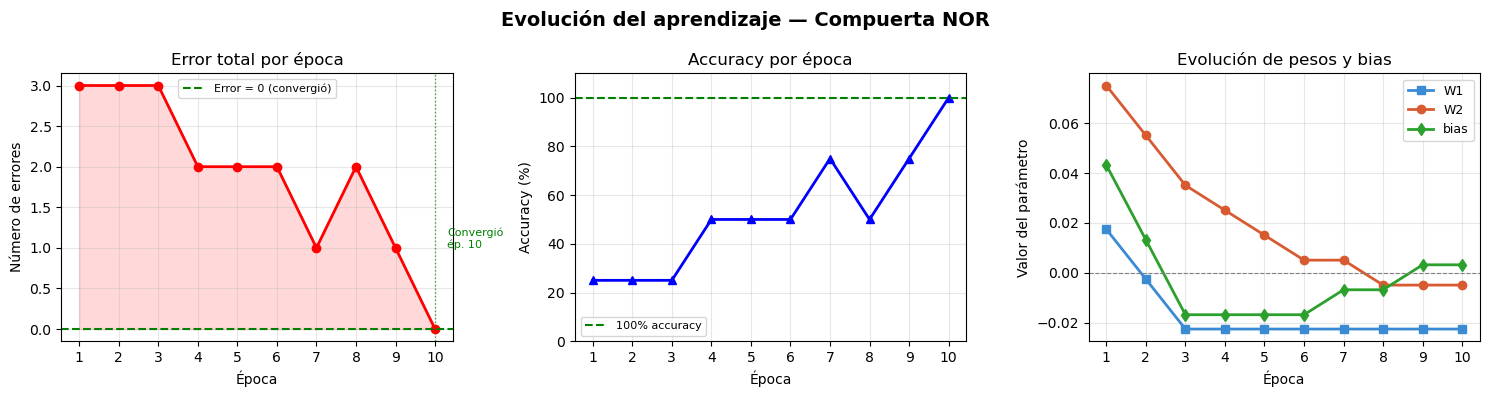

In [8]:
# ═══════════════════════════════════════════════════════════════
# CELDA 7 — Compuerta NOR
# ═══════════════════════════════════════════════════════════════
targets_nor = np.array([1, 0, 0, 0])  # NOR

hist_nor = entrenar_perceptron(
    nombre='NOR',
    inputs=inputs,
    targets=targets_nor,
    learning_rate=0.01,
    epochs=200_000,
    seed=42,
    verbose=True
)

graficar_evolucion('NOR', hist_nor)


═══════════════════════════════════════════════════════
  Perceptrón: NAND
  lr=0.01  epochs=200000  seed=42
═══════════════════════════════════════════════════════
  Pesos iniciales: W1=0.0375  W2=0.0951  b=0.0732

  ── Época 1 ──
   X1  X2  Target  Salida   Error
    0   0       1       1       0
    0   1       1       1       0
    1   0       1       1       0
    1   1       0       1      -1
  Error total: 1  |  Accuracy: 3/4

  ── Época 2 ──
   X1  X2  Target  Salida   Error
    0   0       1       1       0
    0   1       1       1       0
    1   0       1       1       0
    1   1       0       1      -1
  Error total: 1  |  Accuracy: 3/4

  ── Época 3 ──
   X1  X2  Target  Salida   Error
    0   0       1       1       0
    0   1       1       1       0
    1   0       1       1       0
    1   1       0       1      -1
  Error total: 1  |  Accuracy: 3/4

  ── Época 4 ──
   X1  X2  Target  Salida   Error
    0   0       1       1       0
    0   1       1       1       0

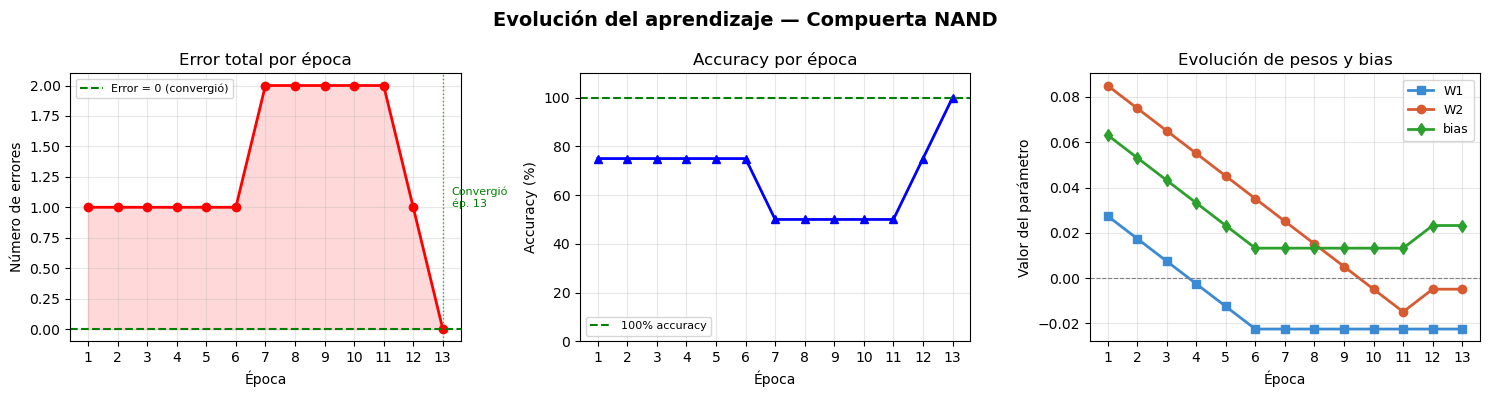

In [9]:
# ═══════════════════════════════════════════════════════════════
# CELDA 8 — Compuerta NAND
# ═══════════════════════════════════════════════════════════════
targets_nand = np.array([1, 1, 1, 0])  # NAND

hist_nand = entrenar_perceptron(
    nombre='NAND',
    inputs=inputs,
    targets=targets_nand,
    learning_rate=0.01,
    epochs=200_000,
    seed=42,
    verbose=True
)

graficar_evolucion('NAND', hist_nand)

---
## Compuerta XOR — ¿Por qué nunca converge?

XOR da 1 cuando las entradas son **diferentes** (0,1 o 1,0) y 0 cuando son iguales.
El problema es que no existe ninguna línea recta que separe los 1s de los 0s.

```
X2
1 |  O (0,1)=1    X (1,1)=0
  |
0 |  X (0,0)=0    O (1,0)=1
  +─────────────────────> X1

Los O (salida=1) están en esquinas opuestas — ninguna línea los separa.
```

la gráfica da error el perceptron **nunca llega a 0** — el perceptrón oscila.


═══════════════════════════════════════════════════════
  Perceptrón: XOR
  lr=0.1  epochs=200  seed=42
═══════════════════════════════════════════════════════
  Pesos iniciales: W1=0.0375  W2=0.0951  b=0.0732

  Pesos finales:   W1=-0.1625  W2=-0.0049  b=0.0732
  ⚠️  No convergió en 200 épocas

═══════════════════════════════════════════════════════
  Compuerta XOR
═══════════════════════════════════════════════════════
+------+------+---------+--------+----------+------+
|   X1 |   X2 |       h |   f(h) |   Target | OK   |
+======+======+=========+========+==========+======+
|    0 |    0 |  0.0732 |      1 |        0 | ❌   |
+------+------+---------+--------+----------+------+
|    0 |    1 |  0.0683 |      1 |        1 | ✅   |
+------+------+---------+--------+----------+------+
|    1 |    0 | -0.0893 |      0 |        1 | ❌   |
+------+------+---------+--------+----------+------+
|    1 |    1 | -0.0943 |      0 |        0 | ✅   |
+------+------+---------+--------+----------+---

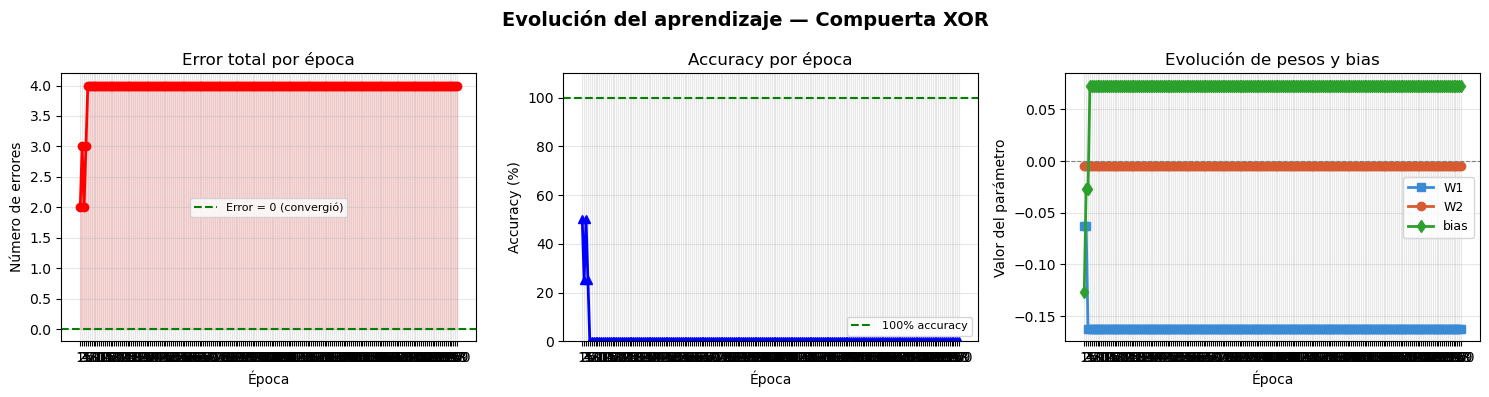


  → El error NUNCA llega a 0
  → Los pesos siguen cambiando (no se estabilizan)
  → El perceptrón oscila sin converger

Solución: usar un Perceptrón Multicapa (MLP)


In [11]:
# ═══════════════════════════════════════════════════════════════
# CELDA 9 — Compuerta XOR (sabemos que fallará)
# ═══════════════════════════════════════════════════════════════
targets_xor = np.array([0, 1, 1, 0])  # XOR

# Usamos más épocas para que se vea claramente que el error no llega a 0
hist_xor = entrenar_perceptron(
    nombre='XOR',
    inputs=inputs,
    targets=targets_xor,
    learning_rate=0.1,
    epochs=200,     # más épocas para ver la oscilación
    seed=42,
    verbose=False  # False para no imprimir tanto texto
)

graficar_evolucion('XOR', hist_xor)

print()
print("  → El error NUNCA llega a 0")
print("  → Los pesos siguen cambiando (no se estabilizan)")
print("  → El perceptrón oscila sin converger")
print()
print("Solución: usar un Perceptrón Multicapa (MLP)")

In [12]:
# ═══════════════════════════════════════════════════════════════
# CELDA 10 — Comparar épocas de convergencia de todas las compuertas
# ═══════════════════════════════════════════════════════════════

def epocas_para_converger(historial):
    """Devuelve la época de convergencia, o None si no convergió."""
    for i, e in enumerate(historial['error_total']):
        if e == 0:
            return i + 1
    return None

resultados_comp = [
    ['OR',   epocas_para_converger(hist_or),   f"{max(hist_or['accuracy']):.0f}%"],
    ['AND',  epocas_para_converger(hist_and),  f"{max(hist_and['accuracy']):.0f}%"],
    ['NOR',  epocas_para_converger(hist_nor),  f"{max(hist_nor['accuracy']):.0f}%"],
    ['NAND', epocas_para_converger(hist_nand), f"{max(hist_nand['accuracy']):.0f}%"],
    ['XOR',  'No converge ❌',                  f"{max(hist_xor['accuracy']):.0f}% (máx)"],
]

print("\n" + "═"*55)
print("  RESUMEN — Comparación de compuertas")
print("═"*55)
print(tabulate(
    resultados_comp,
    headers=['Compuerta', 'Épocas para converger', 'Accuracy final'],
    tablefmt='grid'
))
print()
print("Conclusión: OR, AND, NOR y NAND son linealmente separables")
print("→ El perceptrón las aprende correctamente.")
print("XOR NO es linealmente separable → requiere MLP.")


═══════════════════════════════════════════════════════
  RESUMEN — Comparación de compuertas
═══════════════════════════════════════════════════════
+-------------+-------------------------+------------------+
| Compuerta   | Épocas para converger   | Accuracy final   |
+=============+=========================+==================+
| OR          | 9                       | 100%             |
+-------------+-------------------------+------------------+
| AND         | 8                       | 100%             |
+-------------+-------------------------+------------------+
| NOR         | 10                      | 100%             |
+-------------+-------------------------+------------------+
| NAND        | 13                      | 100%             |
+-------------+-------------------------+------------------+
| XOR         | No converge ❌          | 50% (máx)        |
+-------------+-------------------------+------------------+

Conclusión: OR, AND, NOR y NAND son linealmente separabl